# **Linear regression – Hard-coded less columns in Feature**

This notebook aims to determine possibly positive influence, when hard-coding les columns in $\mathbf{X}$ matrix of features.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

Now we perform masking on the training DataFrame, we obtain less historic columns and presumably we will have wider training window.

In [3]:
columns_shrinked = []
for column in list(TrainingDataFrame.columns):
    for q in range(1, 4):
        if f"_{q}_" in column:
            columns_shrinked.append(column)

# **Linear regression – engine**

In [ ]:
performance_tracker = {}
performance_simple = {}

for ticker in tickers["Ticker"]:
    # Bounded training-validation set
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 180 # Days – variable, more analyses done
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[columns_shrinked].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[columns_shrinked].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()

ACN 1.7528079888157477
ACN 5.022387091141922
ACN 0.4955157512785331
ACN 3.3466928835269654
ACN 0.609782884401089
ACN 4.8812587628658
ACN 1.0299976853306752
ACN 0.5483031632952864
ACN 0.5185407539024058
ACN 0.7879780533283648
ACN 0.982514246273517
ACN 0.8358243788708796
ACN 1.4866765064689913
ACN 1.4929211998946565
ACN 1.0537663374342203
ACN 1.8970026798509139
ACN 1.8210220676021862
ACN 6.306324660095266
ACN 1.4566168489017899
ACN 5.212475441547546
ACN 1.086693863574458
ACN 4.347489858483554
ACN 2.334680844408478
ACN 2.1721531890508383
ACN 0.4051583048422896
ACN 2.9673183829070706
ACN 0.8443151685528629
ACN 1.8557954242482608
ACN 1.9429568219265911
ACN 1.6106962372184577
ACN 4.5298039779882275
ACN 0.4350670156222693
ACN 4.369722770972626
ACN 2.8090424762338633
ACN 5.798914026500636
ACN 1.1198063867754238
ACN 4.562676520175064
ACN 4.297046206130719
ACN 8.897414510299424
ACN 1.597654231100317
ACN 1.364675884445773
ACN 4.962438289606343
ACN 3.810680955878242
ACN 3.2569483522390392
ACN 3.93

In [8]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [ ]:
# MAPE in average
print(np.mean(list(mean_performances.values())))

np.float64(9.557139292847168)

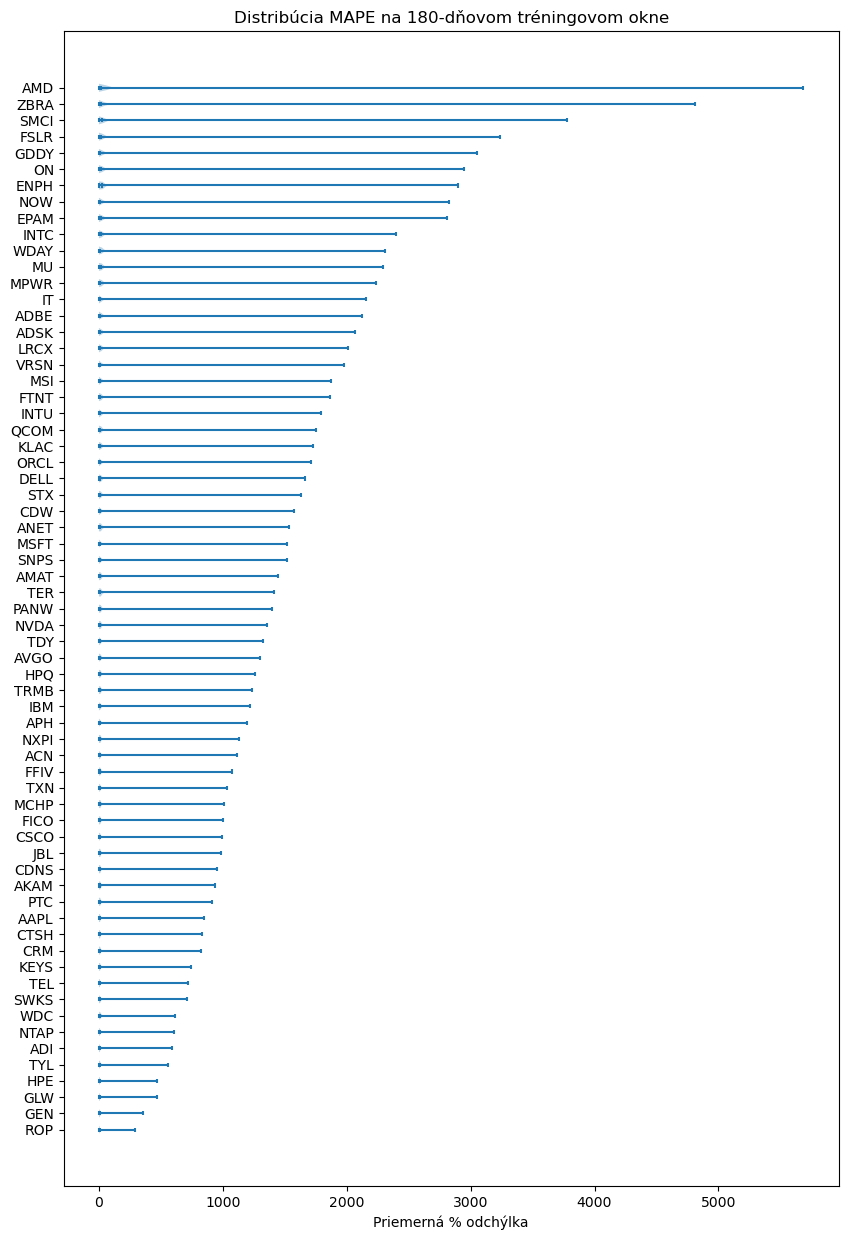

In [10]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [11]:
mean_performances

{'ROP': np.float64(4.6276072330754),
 'TEL': np.float64(5.544277110003375),
 'MSFT': np.float64(5.599321376805913),
 'APH': np.float64(5.731106517209518),
 'AAPL': np.float64(6.038368341416758),
 'CSCO': np.float64(6.180576728201426),
 'TXN': np.float64(6.406480592080107),
 'ADI': np.float64(6.412044958527809),
 'ACN': np.float64(6.4994466506521995),
 'CTSH': np.float64(6.54941485242461),
 'TDY': np.float64(6.6559810885844515),
 'GLW': np.float64(6.760565714998093),
 'VRSN': np.float64(6.818027602014437),
 'IBM': np.float64(6.929612851236137),
 'MSI': np.float64(7.013095115204911),
 'SNPS': np.float64(7.216573999802054),
 'TYL': np.float64(7.377005766628116),
 'HPE': np.float64(7.464597264371272),
 'ORCL': np.float64(7.548548131833331),
 'CDNS': np.float64(7.586356948516531),
 'AVGO': np.float64(7.866287519803071),
 'KEYS': np.float64(7.907365198711544),
 'CDW': np.float64(7.980843028490207),
 'FFIV': np.float64(8.027431414933092),
 'INTU': np.float64(8.095433621266832),
 'NTAP': np.fl

In [12]:
np.mean([np.mean(i) for i in performance_simple.values()])

np.float64(0.1521564651712922)